In [ ]:
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

In [ ]:
!pip install numpy==1.26.4
import os

In [ ]:
!pip install scanpy
!pip install loompy
!pip install datasets

In [ ]:
!git lfs install
!git clone https://huggingface.co/ctheodoris/Geneformer
!ls -1

Git LFS initialized.
fatal: destination path 'Geneformer' already exists and is not an empty directory.
drive
Geneformer
pancreas_output
pancreas_shuffled_filtered_labeled_downsampled_fixednolabel.dataset
sample_data
wandb


In [ ]:
%cd Geneformer
!pip install -e .

/content/Geneformer
Obtaining file:///content/Geneformer
  Preparing metadata (setup.py) ... done
  Attempting uninstall: geneformer
    Found existing installation: geneformer 0.1.0
    Uninstalling geneformer-0.1.0:
      Successfully uninstalled geneformer-0.1.0
  Running setup.py develop for geneformer


In [ ]:
# Mount Google Drive

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

import datetime
import glob
import pickle
import subprocess

import numpy as np
import pandas as pd
import seaborn as sns

from collections import Counter, defaultdict

from datasets import Dataset, DatasetDict, load_from_disk

from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import train_test_split

from transformers import BertForSequenceClassification, Trainer
from transformers.training_args import TrainingArguments

from geneformer import Classifier, DataCollatorForCellClassification, EmbExtractor

In [ ]:
import torch
import gc

# Clear GPU cache
torch.cuda.empty_cache()
gc.collect()

# Check GPU memory
print(f"GPU memory allocated: {torch.cuda.memory_allocated() / 1024**3:.2f} GB")
print(f"GPU memory reserved: {torch.cuda.memory_reserved() / 1024**3:.2f} GB")

GPU memory allocated: 0.00 GB
GPU memory reserved: 0.00 GB


In [ ]:
import torch
torch.cuda.empty_cache()
print(f"CUDA memory after empty_cache: {torch.cuda.memory_allocated() / (1024**3):.2f} GB")

CUDA memory after empty_cache: 0.00 GB


In [ ]:
token_dictionary = "/content/Geneformer/geneformer/token_dictionary_gc104M.pkl"
model_v1 = "/content/Geneformer/Geneformer-V1-10M/"
model_v2 = "/content/Geneformer/Geneformer-V2-104M"

In [ ]:
!cp -r "/content/drive/My Drive/geneformer_test2/pancreas_shuffled_filtered_labeled_downsampled_fixednolabel.dataset" /content/
!ls -l /content/pancreas_shuffled_filtered_labeled_downsampled_fixednolabel.dataset

total 43848
-rw-r--r-- 1 root root 22452096 Jul 30 20:57 cache-77331ea458a5301b.arrow
-rw------- 1 root root 22434416 Jul 30 22:28 data-00000-of-00001.arrow
-rw------- 1 root root      733 Jul 30 22:28 dataset_info.json
-rw------- 1 root root      372 Jul 30 22:28 state.json


In [ ]:
!ls -1 /content/

drive
Geneformer
pancreas_output
pancreas_shuffled_filtered_labeled_downsampled_fixednolabel.dataset
sample_data
wandb


In [ ]:
from datasets import load_from_disk
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
dataset = load_from_disk("/content/pancreas_shuffled_filtered_labeled_downsampled_fixednolabel.dataset")

# Print metadata
print(dataset)
print(dataset.column_names)

# Inspect one example (first row)
example = dataset[0]
print(example.keys())      # list available fields
print(example)             # full content of row 0
print(example['input_ids'])  # list of tokens (gene IDs)

# Check other metadata
print(example['celltype'])
print(example['obs_names'])

# Convert first 10 to DataFrame
df_ex = pd.DataFrame(dataset[:10])
print(df_ex.head())

df_ex = pd.DataFrame(dataset[:])
print(df_ex['celltype'].value_counts())

Dataset({
    features: ['input_ids', 'batch', 'celltype', 'n_counts', 'obs_names', 'size_factors', 'tech', 'length'],
    num_rows: 2000
})
['input_ids', 'batch', 'celltype', 'n_counts', 'obs_names', 'size_factors', 'tech', 'length']
dict_keys(['input_ids', 'batch', 'celltype', 'n_counts', 'obs_names', 'size_factors', 'tech', 'length'])
{'input_ids': [2, 10361, 6490, 215, 12665, 2775, 7016, 1353, 3578, 13094, 11560, 14947, 18617, 8319, 11215, 583, 10112, 6982, 9835, 13423, 14489, 2606, 13747, 6918, 13737, 14643, 13247, 6113, 8960, 16629, 1003, 5957, 15463, 5184, 7944, 5132, 14470, 131, 325, 11968, 4856, 2752, 5473, 228, 1950, 10315, 636, 13482, 7749, 3639, 686, 12301, 6514, 17305, 4542, 16936, 16637, 3105, 1718, 726, 10705, 18770, 2960, 4559, 19132, 7405, 12483, 799, 7898, 4525, 1789, 17062, 11713, 245, 3161, 8118, 18477, 6602, 14215, 9614, 4818, 3234, 8987, 5383, 5585, 17182, 1032, 3480, 4506, 5752, 1320, 2338, 1819, 15958, 3714, 6253, 5158, 7651, 9689, 1354, 806, 15103, 6640, 13971,

In [ ]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
import os
import glob
import datetime
import numpy as np
import pandas as pd
from datasets import load_from_disk, Dataset, DatasetDict
from sklearn.model_selection import train_test_split
from collections import defaultdict
from geneformer import Classifier, EmbExtractor

In [ ]:
import os
from datasets import load_from_disk
from sklearn.model_selection import train_test_split
import pandas as pd
from datasets import Dataset

# Add split column to dataset that's missing it

print("🔧 ADDING SPLIT COLUMN TO DATASET...")

# Load the dataset that's missing split column
print(f"Original dataset:")
print(f"  Size: {len(dataset)}")
print(f"  Columns: {list(dataset.features.keys())}")
print(f"  Has 'split' column: {'split' in dataset.features}")

# Check cell type distribution
from collections import Counter
celltype_counts = Counter(dataset['celltype'])
print(f"\nCell type distribution:")
for celltype, count in celltype_counts.most_common():
    pct = 100 * count / len(dataset)
    print(f"  {celltype}: {count} cells ({pct:.1f}%)")

🔧 ADDING SPLIT COLUMN TO DATASET...
Original dataset:
  Size: 2000
  Columns: ['input_ids', 'batch', 'celltype', 'n_counts', 'obs_names', 'size_factors', 'tech', 'length']
  Has 'split' column: False

Cell type distribution:
  alpha: 815 cells (40.8%)
  beta: 619 cells (30.9%)
  ductal: 318 cells (15.9%)
  acinar: 248 cells (12.4%)


**We should NOT use pandas for split, as it may interfere with tensor packages, tensor operations, and the HuggingFace transformers**

Why Datasets Library is Better:

1. No Tensor Interference
✅ Pure datasets operations - no pandas DataFrames
✅ Compatible with HuggingFace ecosystem
✅ No type conversion issues
✅ Maintains tensor compatibility

2. Memory Efficient
✅ No pandas overhead
✅ Direct dataset operations
✅ Lazy loading support
✅ Better for large datasets

3. HuggingFace Native
✅ Built for transformers
✅ Seamless integration
✅ Optimized for ML workflows

In [ ]:
# =============================================================================
# CREATE STRATIFIED SPLITS
# =============================================================================

# print("\n📊 Creating stratified train/eval/test splits...")

# Convert to pandas for stratified splitting
# df = dataset.to_pandas()

# First split: 80% train+eval, 20% test
# train_eval_df, test_df = train_test_split(
#    df,
#    test_size=0.2,
#    stratify=df['celltype'],
#    random_state=42
# )

# Second split: 70% train, 10% eval (from the 80%)
# train_df, eval_df = train_test_splittrain_test_split(
#    train_eval_df,
#    test_size=0.125,  # 10% of total = 12.5% of 80%
#    stratify=train_eval_df['celltype'],
#    random_state=42
# )

# Add split labels
# train_df['split'] = 'train'
# eval_df['split'] = 'eval'
# test_df['split'] = 'test'

# Combine all splits
# combined_df = pd.concat([train_df, eval_df, test_df], ignore_index=True)

# print(f"\nSplit sizes:")
# print(f"  Train: {len(train_df)} cells")
# print(f"  Eval: {len(eval_df)} cells")
# print(f"  Test: {len(test_df)} cells")

# Verify split distribution
# split_counts = Counter(combined_df['split'])
# print(f"Split verification: {dict(split_counts)}")

# Check cell type distribution per split
# print(f"\nCell type distribution per split:")
# for split_name in ['train', 'eval', 'test']:
#    split_data = combined_df[combined_df['split'] == split_name]
#    split_celltype_counts = Counter(split_data['celltype'])
#    print(f"  {split_name.upper()}:")
#    for celltype, count in split_celltype_counts.most_common():
#        pct = 100 * count / len(split_data)
#        print(f"    {celltype}: {count} cells ({pct:.1f}%)")

# =============================================================================
# SAVE THE COMPLETE DATASET
# =============================================================================

# Convert back to Dataset (remove pandas index)
# final_dataset = Dataset.from_pandas(combined_df, preserve_index=False)

# Save the dataset with splits
# complete_dataset_path = "/content/pancreas_complete_with_splits.dataset"
# final_dataset.save_to_disk(complete_dataset_path)

In [ ]:
 # Set environment variables for CUDA
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

# =============================================================================
# SECTION 0: SETUP AND CONFIGURATION
# =============================================================================

print("🚀 Starting Pancreas Geneformer Classification Pipeline")
print("="*60)

# Create timestamp for output
current_date = datetime.datetime.now()
datestamp = f"{str(current_date.year)[-2:]}{current_date.month:02d}{current_date.day:02d}{current_date.hour:02d}{current_date.minute:02d}{current_date.second:02d}"
datestamp_min = f"{str(current_date.year)[-2:]}{current_date.month:02d}{current_date.day:02d}"

# Output configuration
output_prefix = "pancreas_classifier"
output_dir = f"/content/pancreas_output/{datestamp}"
os.makedirs(output_dir, exist_ok=True)

print(f"📁 Output directory: {output_dir}")
print(f"🏷️  Output prefix: {output_prefix}")

# No filtering - use all cell types
filter_data_dict = None
print(f"🔍 Cell types to classify: ALL cell types (no filtering)")

# Training hyperparameters
training_args = {
    "num_train_epochs": 0.9,
    "learning_rate": 0.0008,
    "lr_scheduler_type": "polynomial",
    "warmup_steps": 500,
    "weight_decay": 0.03,
    "per_device_train_batch_size": 8,
    "seed": 42,
    "gradient_checkpointing": False,
    "fp16": False,
}

print(f"⚙️  Training configuration:")
for key, value in training_args.items():
    print(f"  {key}: {value}")


🚀 Starting Pancreas Geneformer Classification Pipeline
📁 Output directory: /content/pancreas_output/250730222804
🏷️  Output prefix: pancreas_classifier
🔍 Cell types to classify: ALL cell types (no filtering)
⚙️  Training configuration:
  num_train_epochs: 0.9
  learning_rate: 0.0008
  lr_scheduler_type: polynomial
  warmup_steps: 500
  weight_decay: 0.03
  per_device_train_batch_size: 8
  seed: 42
  gradient_checkpointing: False
  fp16: False


In [ ]:
# Load the original pancreas dataset
dataset = load_from_disk("/content/pancreas_shuffled_filtered_labeled_downsampled_fixednolabel.dataset")

print(f"✅ Dataset loaded successfully!")
print(f"📊 Total cells: {len(dataset)}")
print(f"📋 Available columns: {dataset.column_names}")

# Display sample data structure
print(f"\n🔍 Sample data structure:")
example = dataset[0]
for key, value in example.items():
    if isinstance(value, list) and len(value) > 10:
        print(f"  {key}: [list of {len(value)} items] (first 5: {value[:5]}...)")
    else:
        print(f"  {key}: {value}")

# Show available cell types in the dataset
print(f"\n🏷️  Available cell types in dataset:")
celltype_counts = Counter([example["celltype"] for example in dataset])
for celltype, count in celltype_counts.items():
    print(f"  {celltype}: {count} cells")
print(f"  Total unique cell types: {len(celltype_counts)}")

✅ Dataset loaded successfully!
📊 Total cells: 2000
📋 Available columns: ['input_ids', 'batch', 'celltype', 'n_counts', 'obs_names', 'size_factors', 'tech', 'length']

🔍 Sample data structure:
  input_ids: [list of 1078 items] (first 5: [2, 10361, 6490, 215, 12665]...)
  batch: indrop
  celltype: alpha
  n_counts: 1091
  obs_names: human2_lib2.final_cell_0545
  size_factors: 0.011693908631536217
  tech: inDrop2
  length: 1078

🏷️  Available cell types in dataset:
  alpha: 815 cells
  beta: 619 cells
  ductal: 318 cells
  acinar: 248 cells
  Total unique cell types: 4


In [ ]:
# =============================================================================
# SECTION 2: CREATE STRATIFIED SPLITS (DATASETS-BASED)
# =============================================================================

print(f"\n📊 Creating stratified train/eval/test splits using datasets library...")

# Method 1: Using datasets library with train_test_split on indices
def create_stratified_splits_datasets(dataset, train_ratio=0.7, eval_ratio=0.15, test_ratio=0.15, random_state=42):
    """
    Create stratified splits using datasets library (no pandas)
    """
    print(f"Creating splits: {train_ratio*100:.0f}% train, {eval_ratio*100:.0f}% eval, {test_ratio*100:.0f}% test")

    # Get all indices and celltypes
    indices = list(range(len(dataset)))
    celltypes = [dataset['celltype'][i] for i in indices]

    # First split: train+eval vs test
    trainval_indices, test_indices = train_test_split(
        indices,
        test_size=test_ratio,
        stratify=celltypes,
        random_state=random_state
    )

    # Second split: train vs eval
    celltypes_trainval = [celltypes[i] for i in trainval_indices]
    train_ratio_adjusted = eval_ratio / (train_ratio + eval_ratio)
    train_indices, eval_indices = train_test_split(
        trainval_indices,
        test_size=train_ratio_adjusted,
        stratify=celltypes_trainval,
        random_state=random_state
    )

    # Create split labels
    split_labels = [''] * len(dataset)
    for i in train_indices:
        split_labels[i] = 'train'
    for i in eval_indices:
        split_labels[i] = 'eval'
    for i in test_indices:
        split_labels[i] = 'test'

    return split_labels, {
        'train_indices': train_indices,
        'eval_indices': eval_indices,
        'test_indices': test_indices
    }

# Create splits
split_labels, split_info = create_stratified_splits_datasets(dataset)

# Add splits to dataset using datasets library
print(f"Adding split labels to dataset...")
dataset = dataset.map(lambda example, idx: {"split": split_labels[idx]}, with_indices=True)

# Display split distribution
split_counts = Counter([example["split"] for example in dataset])
print(f"\n📊 Split distribution:")
for split, count in split_counts.items():
    print(f"  {split}: {count} cells")

# Verify stratification
print(f"\n🏷️  Cell type distribution per split:")
for split_name in ['train', 'eval', 'test']:
    split_data = [example for example in dataset if example['split'] == split_name]
    split_celltype_counts = Counter([example['celltype'] for example in split_data])
    print(f"  {split_name.upper()}:")
    for celltype, count in split_celltype_counts.most_common():
        pct = 100 * count / len(split_data)
        print(f"    {celltype}: {count} cells ({pct:.1f}%)")

# Save dataset with splits
complete_dataset_path = f"{output_dir}/pancreas_with_splits_ready.dataset"
dataset.save_to_disk(complete_dataset_path)
print(f"✅ Dataset with splits saved to: {complete_dataset_path}")


📊 Creating stratified train/eval/test splits using datasets library...
Creating splits: 70% train, 15% eval, 15% test
Adding split labels to dataset...

📊 Split distribution:
  train: 1400 cells
  test: 300 cells
  eval: 300 cells

🏷️  Cell type distribution per split:
  TRAIN:
    alpha: 571 cells (40.8%)
    beta: 433 cells (30.9%)
    ductal: 222 cells (15.9%)
    acinar: 174 cells (12.4%)
  EVAL:
    alpha: 122 cells (40.7%)
    beta: 93 cells (31.0%)
    ductal: 48 cells (16.0%)
    acinar: 37 cells (12.3%)
  TEST:
    alpha: 122 cells (40.7%)
    beta: 93 cells (31.0%)
    ductal: 48 cells (16.0%)
    acinar: 37 cells (12.3%)
✅ Dataset with splits saved to: /content/pancreas_output/250730222804/pancreas_with_splits_ready.dataset


In [ ]:
# =============================================================================
# SECTION 3: INITIALIZE CLASSIFIER
# =============================================================================

print(f"\n🔧 Initializing pancreas cell type classifier...")

# Initialize classifier
cc = Classifier(
    classifier="cell",
    cell_state_dict={"state_key": "celltype", "states": "all"},
    filter_data=filter_data_dict,
    training_args=training_args,
    max_ncells=None,
    freeze_layers=2,
    num_crossval_splits=1,
    stratify_splits_col="celltype",
    forward_batch_size=8,
    model_version="V2",
    nproc=8,
    ngpu=1
)

print("✅ Classifier initialized successfully")
print(f"🎯 Classification target: celltype")
print(f"🔒 Freeze layers: 2")
print(f"🔄 Model version: V2")



🔧 Initializing pancreas cell type classifier...
✅ Classifier initialized successfully
🎯 Classification target: celltype
🔒 Freeze layers: 2
🔄 Model version: V2


In [ ]:
# =============================================================================
# SECTION 4: DEFINE SPLIT CONFIGURATIONS
# =============================================================================

print(f"\n⚙️  Defining split configurations...")

# Split configuration for train/test
train_test_id_split_dict = {
    "attr_key": "split",
    "train": ["train", "eval"],
    "test": ["test"]
}

# Split configuration for train/validation
train_valid_id_split_dict = {
    "attr_key": "split",
    "train": ["train"],
    "eval": ["eval"]
}

print(f"✅ Split configurations defined")


⚙️  Defining split configurations...
✅ Split configurations defined


In [ ]:
# =============================================================================
# SECTION 5: PREPARE DATA FOR TRAINING
# =============================================================================

print(f"\n📋 Preparing data for training...")

try:
    cc.prepare_data(
        input_data_file=complete_dataset_path,
        output_directory=output_dir,
        output_prefix=output_prefix,
        split_id_dict=train_test_id_split_dict
    )
    print("✅ Data preparation completed successfully!")
except Exception as e:
    print(f"❌ Data preparation failed: {e}")
    raise



📋 Preparing data for training...
✅ Data preparation completed successfully!


In [ ]:
# =============================================================================
# SECTION 6: TRAIN THE MODEL
# =============================================================================

print(f"\n🚀 Training pancreas cell type classifier...")

# Model path for V2
model_path = "/content/Geneformer/Geneformer-V2-104M"
print(f"🔬 Using model: {model_path}")

try:
    all_metrics = cc.validate(
        model_directory=model_path,
        prepared_input_data_file=f"{output_dir}/{output_prefix}_labeled_train.dataset",
        id_class_dict_file=f"{output_dir}/{output_prefix}_id_class_dict.pkl",
        output_directory=output_dir,
        output_prefix=output_prefix,
        split_id_dict=train_valid_id_split_dict
    )

    print("✅ Training completed successfully!")
    print(f"📊 Training metrics: {all_metrics}")

except Exception as e:
    print(f"❌ Training failed: {e}")
    raise



🚀 Training pancreas cell type classifier...
🔬 Using model: /content/Geneformer/Geneformer-V2-104M


  0%|          | 0/1 [00:00<?, ?it/s]

****** Validation split: 1/1 ******



Some weights of BertForSequenceClassification were not initialized from the model checkpoint at /content/Geneformer/Geneformer-V2-104M and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
wandb: WARNING The `run_name` is currently set to the same value as `TrainingArguments.output_dir`. If this was not intended, please specify a different run name by setting the `TrainingArguments.run_name` parameter.
wandb: Currently logged in as: bogdan-tanasa (bogdan-tanasa-university-of-california) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


/content/Geneformer/geneformer/collator_for_classification.py:649: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  batch = {k: torch.tensor(v.clone().detach(), dtype=torch.int64) if isinstance(v, torch.Tensor) else torch.tensor(v, dtype=torch.int64) for k, v in batch.items()}


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
0,0.521500,0.100258,0.983333,0.973535


  0%|          | 0/38 [00:00<?, ?it/s]

✅ Training completed successfully!
📊 Training metrics: {'conf_matrix':         ductal  acinar  alpha  beta
ductal    47.0     1.0    0.0   0.0
acinar     3.0    34.0    0.0   0.0
alpha      0.0     0.0  122.0   0.0
beta       0.0     0.0    1.0  92.0, 'macro_f1': [0.9735352699638414], 'acc': [0.9833333333333333], 'all_roc_metrics': None}


In [ ]:
# =============================================================================
# SECTION 7: EVALUATE ON TEST SET
# =============================================================================

print(f"\n🧪 Evaluating model on test set...")

# Initialize evaluation classifier
eval_cc = Classifier(
    classifier="cell",
    cell_state_dict={"state_key": "celltype", "states": "all"},
    forward_batch_size=8,
    nproc=8
)

try:
    all_metrics_test = eval_cc.evaluate_saved_model(
        model_directory=f"{output_dir}/{datestamp_min}_geneformer_cellClassifier_{output_prefix}/ksplit1/",
        id_class_dict_file=f"{output_dir}/{output_prefix}_id_class_dict.pkl",
        test_data_file=f"{output_dir}/{output_prefix}_labeled_test.dataset",
        output_directory=output_dir,
        output_prefix=output_prefix,
    )

    print("✅ Test evaluation completed successfully!")
    print(f"📊 Test metrics: {all_metrics_test}")

except Exception as e:
    print(f"❌ Test evaluation failed: {e}")
    raise



🧪 Evaluating model on test set...


  0%|          | 0/38 [00:00<?, ?it/s]

✅ Test evaluation completed successfully!
📊 Test metrics: {'conf_matrix':         ductal  acinar  alpha  beta
ductal      45       2      1     0
acinar       2      35      0     0
alpha        0       0    122     0
beta         0       2      4    87, 'macro_f1': 0.9537518495032762, 'acc': 0.9633333333333334, 'all_roc_metrics': None}



📊 Creating visualizations...


<Figure size 1000x1000 with 0 Axes>

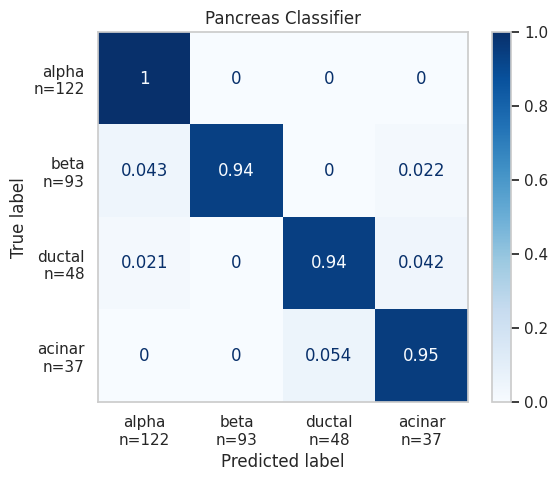

✅ Confusion matrix saved!
✅ Predictions plot saved!


<Figure size 1500x1500 with 0 Axes>

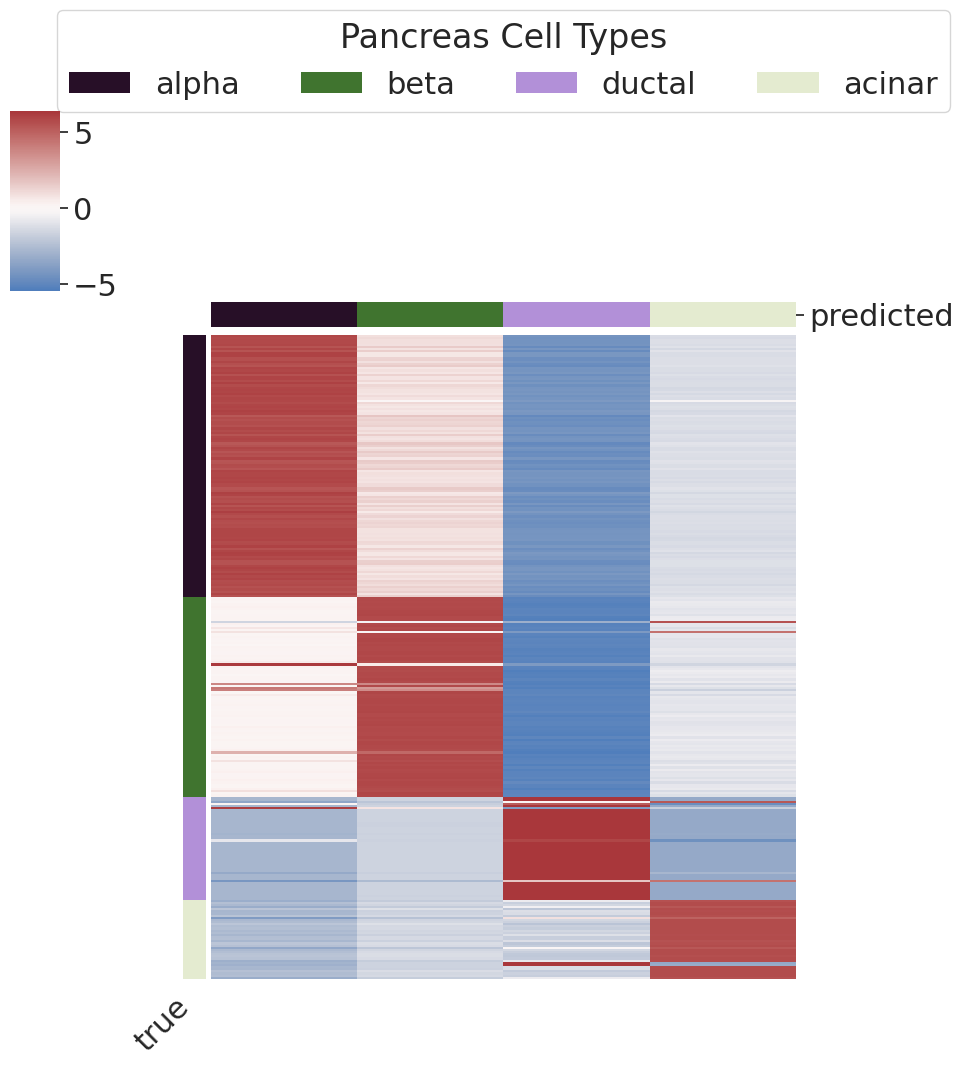

In [ ]:
# =============================================================================
# SECTION 8: CREATE VISUALIZATIONS
# =============================================================================

print(f"\n📊 Creating visualizations...")

# Get unique cell types for plotting
unique_celltypes = list(celltype_counts.keys())

# Plot confusion matrix
try:
    eval_cc.plot_conf_mat(
        conf_mat_dict={"Pancreas Classifier": all_metrics_test["conf_matrix"]},
        output_directory=output_dir,
        output_prefix=output_prefix,
        custom_class_order=unique_celltypes,
    )
    print("✅ Confusion matrix saved!")
except Exception as e:
    print(f"❌ Confusion matrix plotting failed: {e}")

# Plot predictions
try:
    eval_cc.plot_predictions(
        predictions_file=f"{output_dir}/{output_prefix}_pred_dict.pkl",
        id_class_dict_file=f"{output_dir}/{output_prefix}_id_class_dict.pkl",
        title="Pancreas Cell Types",
        output_directory=output_dir,
        output_prefix=output_prefix,
        custom_class_order=unique_celltypes,
    )
    print("✅ Predictions plot saved!")
except Exception as e:
    print(f"❌ Predictions plotting failed: {e}")


In [ ]:

# =============================================================================
# SECTION 9: FINAL RESULTS SUMMARY
# =============================================================================

print(f"\n🎉 PANCREAS CLASSIFICATION ANALYSIS COMPLETE!")
print("="*60)
print(f"📁 Output directory: {output_dir}")
print(f"🔬 Model: Geneformer V2")
print(f"📊 Dataset size: {len(dataset)} cells")
print(f"🏷️  Cell types: {list(celltype_counts.keys())}")

# Display final metrics
if 'all_metrics_test' in locals():
    print(f"\n📈 FINAL PERFORMANCE METRICS:")
    print(f"  🎯 Accuracy: {all_metrics_test.get('acc', 'N/A'):.4f}")
    print(f"  🎯 Macro F1: {all_metrics_test.get('macro_f1', 'N/A'):.4f}")

    if 'conf_matrix' in all_metrics_test:
        print(f"  📊 Confusion Matrix Shape: {all_metrics_test['conf_matrix'].shape}")

# List generated files
print(f"\n📄 Generated files:")
for file in os.listdir(output_dir):
    if output_prefix in file:
        if any(x in file for x in ['.png', 'confusion', 'plot']):
            print(f"  🎨 {file}")
        else:
            print(f"  📄 {file}")

print(f"\n✅ Analysis complete! Check {output_dir} for all results and visualizations.")


🎉 PANCREAS CLASSIFICATION ANALYSIS COMPLETE!
📁 Output directory: /content/pancreas_output/250730222804
🔬 Model: Geneformer V2
📊 Dataset size: 2000 cells
🏷️  Cell types: ['alpha', 'beta', 'ductal', 'acinar']

📈 FINAL PERFORMANCE METRICS:
  🎯 Accuracy: 0.9633
  🎯 Macro F1: 0.9538
  📊 Confusion Matrix Shape: (4, 4)

📄 Generated files:
  📄 pancreas_classifier_conf_mat.pdf
  📄 pancreas_classifier_pred_dict.pkl
  📄 pancreas_classifier_test_metrics_dict.pkl
  📄 pancreas_classifier_labeled_train.dataset
  📄 250730_geneformer_cellClassifier_pancreas_classifier
  📄 pancreas_classifier_id_class_dict.pkl
  📄 pancreas_classifier_pred.pdf
  📄 pancreas_classifier_labeled_test.dataset

✅ Analysis complete! Check /content/pancreas_output/250730222804 for all results and visualizations.
